# TD法
教科書P174のコードを試す。

In [1]:
import sys, os
sys.path.append(os.pardir)

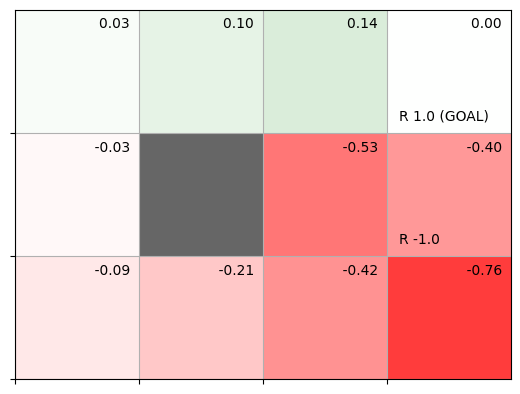

In [2]:
from td_eval import *
from common.gridworld import *

env = GridWorld()
agent = TdAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.eval(state, reward, next_state, done) # 毎回呼ぶ
        if done:
            break
        state = next_state

env.render_v(agent.V)

## SarsaAgentクラスを動かす

`deque`を用いているため、`agent.memory`に格納されている第1要素が「現在の状態についての情報」である。

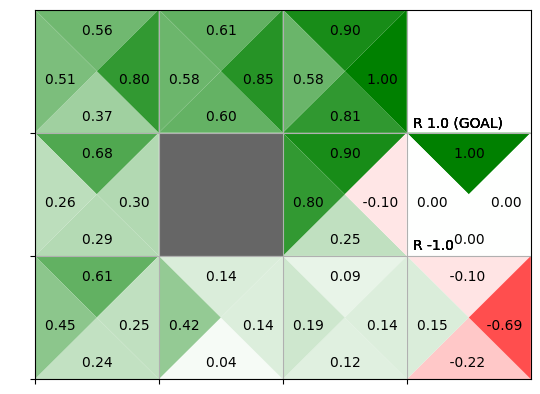

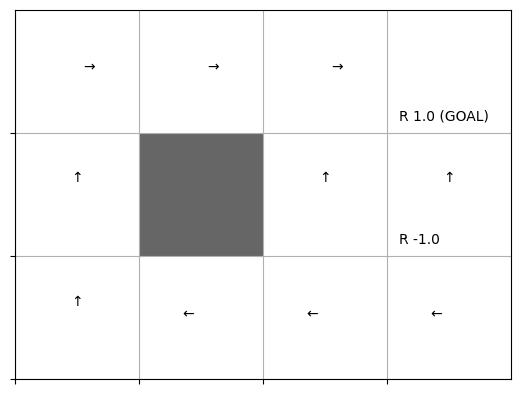

In [ ]:
import sys, os
sys.path.append(os.pardir)

from sarsa import SarsaAgent
from common.gridworld import *

env = GridWorld()
agent = SarsaAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action) # next_stateがゴールのときに`done = True`となることに注意せよ。

        agent.update(state, action, reward, done)   # 毎回呼ぶ（Agentが進む（行動する）ごとに更新するので）

        if done:
            agent.update(next_state, None, None, None)  # ゴールに到達したときは、その後の行動(action)と報酬(reward)、その次がゴールかどうかの判定(done)に情報はないので、それらは`None`として実装する。
            # そしてSARSAでは、今と次の状態と行動のデータによって更新するので、ゴールに到達したときも、方策を改善する。
            # agent.updateがここで実行されて初めて、現在の状態がagent.memoryインスタンス変数の第0要素へと格納されるため、その状態でQ関数の値を更新することができる（最後のステップで、次の状態がゴールの時の値も考慮されたQ関数の値の更新が可能）。
            break
        state = next_state

env.render_q(agent.Q)